# Analysis of Age-Specific Marker Expression Post-Integration

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 9th January 2025\
**Last modified date:** 9th January 2025

In this notebook, we analyze the expression of age-specific markers—genes uniquely expressed in the first trimester, second trimester, and adulthood—in the human gut. This analysis aims to determine whether correcting for age groups during data integration preserves or removes important biological variability.

## Import package

In [1]:
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime

## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
timestamp

'14012025_123640'

* Upload datasets

In [ ]:
adata_corrected = sc.read_h5ad('integration_of_remapped_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_23122024_151117_raw.h5ad')
adata_corrected

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [ ]:
adata_uncorrected = sc.read_h5ad('integration_of_remapped_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata_uncorrected

/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

* Normalize datasets

In [6]:
adata_corrected = adata_corrected.copy()
sc.pp.normalize_total(adata_corrected, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_corrected)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'C1QB', 'GUCA2B', 'GUCA2A', 'JUN', 'CLCA1', 'ATP1A1-AS1', 'REG4', 'S100A9', 'S100A12', 'S100A8', 'S100A6', 'RPS27', 'ITLN1', 'ITLN2', 'APOA2', 'PIGR', 'ACTG2', 'REG1A', 'REG3A', 'TMSB10', 'GNLY', 'FABP1', 'IGKV4-1', 'IGKV2D-29', 'IGKV2D-24', 'IGKV3D-20', 'IGKV1D-16', 'IGKV1D-13', 'IGKV3D-11', 'GCG', 'CRYBA2', 'CCL20', 'GHRL', 'CCK', 'RBP2', 'MFSD1', 'SST', 'APOD', 'FDCSP', 'ENSG00000286848', 'JCHAIN', 'GC', 'ALB', 'AFP', 'CXCL8', 'CXCL10', 'CXCL13', 'SPP1', 'MMRN1', 'RPL34', 'CCDC152', 'GZMA', 'ATG10', 'CXCL14', 'SPINK1', 'CD74', 'GPX3', 'FABP6', 'SOX4', 'ENSG00000271581', 'MLN', 'ENSG00000287089', 'CLPS', 'LINC01013', 'ACTB', 'AGR2', 'CD36', 'COL1A2', 'TAC1', 'ADAMDEC1', 'CLU', 'ENSG00000272256', 'RPL30-AS1', 'RPS6', 'SPINK4', 'CCL19', 'CCL21', 'TPM2', 'TXN', 'GSN', 'RPL12', 'LCN2', 'LCN15', 'VIM-AS1', 'PSAP', 'C10orf55', 'ADIRF-AS1', 'SHLD2', 'ACTA

In [15]:
adata_uncorrected = adata_uncorrected.copy()
sc.pp.normalize_total(adata_uncorrected, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_uncorrected)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'C1QB', 'GUCA2B', 'GUCA2A', 'JUN', 'CLCA1', 'ATP1A1-AS1', 'REG4', 'S100A9', 'S100A12', 'S100A8', 'S100A6', 'RPS27', 'ITLN1', 'ITLN2', 'APOA2', 'PIGR', 'ACTG2', 'REG1A', 'REG3A', 'TMSB10', 'GNLY', 'FABP1', 'IGKV4-1', 'IGKV2D-29', 'IGKV2D-24', 'IGKV3D-20', 'IGKV1D-16', 'IGKV1D-13', 'IGKV3D-11', 'GCG', 'CRYBA2', 'CCL20', 'GHRL', 'CCK', 'RBP2', 'MFSD1', 'SST', 'APOD', 'FDCSP', 'ENSG00000286848', 'JCHAIN', 'GC', 'ALB', 'AFP', 'CXCL8', 'CXCL10', 'CXCL13', 'SPP1', 'MMRN1', 'RPL34', 'CCDC152', 'GZMA', 'ATG10', 'CXCL14', 'SPINK1', 'CD74', 'GPX3', 'FABP6', 'SOX4', 'ENSG00000271581', 'MLN', 'ENSG00000287089', 'CLPS', 'LINC01013', 'ACTB', 'AGR2', 'CD36', 'COL1A2', 'TAC1', 'ADAMDEC1', 'CLU', 'ENSG00000272256', 'RPL30-AS1', 'RPS6', 'SPINK4', 'CCL19', 'CCL21', 'TPM2', 'TXN', 'GSN', 'RPL12', 'LCN2', 'LCN15', 'VIM-AS1', 'PSAP', 'C10orf55', 'ADIRF-AS1', 'SHLD2', 'ACTA

* Define markers

In [8]:
markers = {
    'first_trimester': ['HMGA2', 'GATA4', 'ONECUT2', 'VTN', 'FOXD1', 'LEFTY1', 'HEYA1', 'SOX13', 'RSPO3'],
    'second_trimester': ['SOX6', 'IL18', 'ENTPD2', 'LGR5', 'ASCL2', 'FOXD1', 'LEFTY1', 'HEYA1', 'SOX13', 'CXCL13'],
    'adult': ['F3', 'TCF4', 'FOXA2',  'SOX9', 'LGR5', 'ASCL2', 'CXCL13']
}

### UMAP plots

+ First trimester

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_corrected,color=['age_group', 'HMGA2', 'GATA4', 'ONECUT2', 'VTN', 'FOXD1', 'LEFTY1', 'SOX13', 'RSPO3'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/first_trimester_markers_age_group_corrected.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_uncorrected,color=['age_group', 'HMGA2', 'GATA4', 'ONECUT2', 'VTN', 'FOXD1', 'LEFTY1', 'SOX13', 'RSPO3'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/first_trimester_markers_age_group_uncorrected.png", bbox_inches="tight")
    plt.show()

+ Second trimester

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_corrected,color=['age_group', 'SOX6', 'IL18', 'ENTPD2', 'LGR5', 'ASCL2', 'FOXD1', 'LEFTY1', 'SOX13', 'CXCL13'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/second_trimester_markers_age_group_corrected.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_uncorrected,color=['age_group', 'SOX6', 'IL18', 'ENTPD2', 'LGR5', 'ASCL2', 'FOXD1', 'LEFTY1', 'SOX13', 'CXCL13'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/second_trimester_markers_age_group_uncorrected.png", bbox_inches="tight")
    plt.show()

+ Adult 

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_corrected,color=['age_group', 'F3', 'TCF4', 'FOXA2',  'SOX9', 'LGR5', 'ASCL2', 'CXCL13'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/adult_markers_age_group_corrected.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata_uncorrected,color=['age_group', 'F3', 'TCF4', 'FOXA2',  'SOX9', 'LGR5', 'ASCL2', 'CXCL13'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/adult_markers_age_group_uncorrected.png", bbox_inches="tight")
    plt.show()

* Ridgeplots

In [37]:
def plot_ridges_for_genes(adata, genes, age_group_col='age_group', min_exp=0.1):
    fig, axes = plt.subplots(len(genes), 1, figsize=(10, 4*len(genes)))
    if len(genes) == 1:
        axes = [axes]
    
    age_groups = adata.obs[age_group_col].cat.categories if hasattr(adata.obs[age_group_col], 'cat') else sorted(adata.obs[age_group_col].unique())
    
    for ax, gene in zip(axes, genes):
        for age in age_groups:
            mask = adata.obs[age_group_col] == age
            if isinstance(adata.X, np.ndarray):
                exp = adata[mask, gene].X
            else:
                exp = adata[mask, gene].X.toarray().flatten()
            
            exp_filtered = exp[exp >= min_exp]
            
            # Only plot if we have non-zero expressions
            if len(exp_filtered) > 0:
                sns.kdeplot(
                    data=exp_filtered,
                    label=f"{age}",
                    ax=ax
                )
        
        ax.set_title(f"{gene} expression across age groups")
        ax.set_xlabel("Expression")
        ax.set_ylabel("Density")
        #ax.set_xscale('log')  # Set log scale ?
        ax.legend(title="Age group", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    return fig

In [ ]:
genes_to_plot = ['HMGA2', 'GATA4', 'ONECUT2', 'VTN', 'FOXD1', 'LEFTY1', 'SOX13', 'RSPO3']
fig = plot_ridges_for_genes(adata_corrected, genes_to_plot)
plt.show()

In [ ]:
genes_to_plot = ['HMGA2', 'GATA4', 'ONECUT2', 'VTN', 'FOXD1', 'LEFTY1', 'SOX13', 'RSPO3'] 
fig = plot_ridges_for_genes(adata_uncorrected, genes_to_plot)
plt.show()

In [ ]:
genes_to_plot = ['SOX6', 'IL18', 'ENTPD2', 'LGR5', 'ASCL2', 'FOXD1', 'LEFTY1', 'SOX13', 'CXCL13'] 
fig = plot_ridges_for_genes(adata_corrected, genes_to_plot)
plt.show()

In [ ]:
genes_to_plot = ['SOX6', 'IL18', 'ENTPD2', 'LGR5', 'ASCL2', 'FOXD1', 'LEFTY1', 'SOX13', 'CXCL13'] 
fig = plot_ridges_for_genes(adata_uncorrected, genes_to_plot)
plt.show()

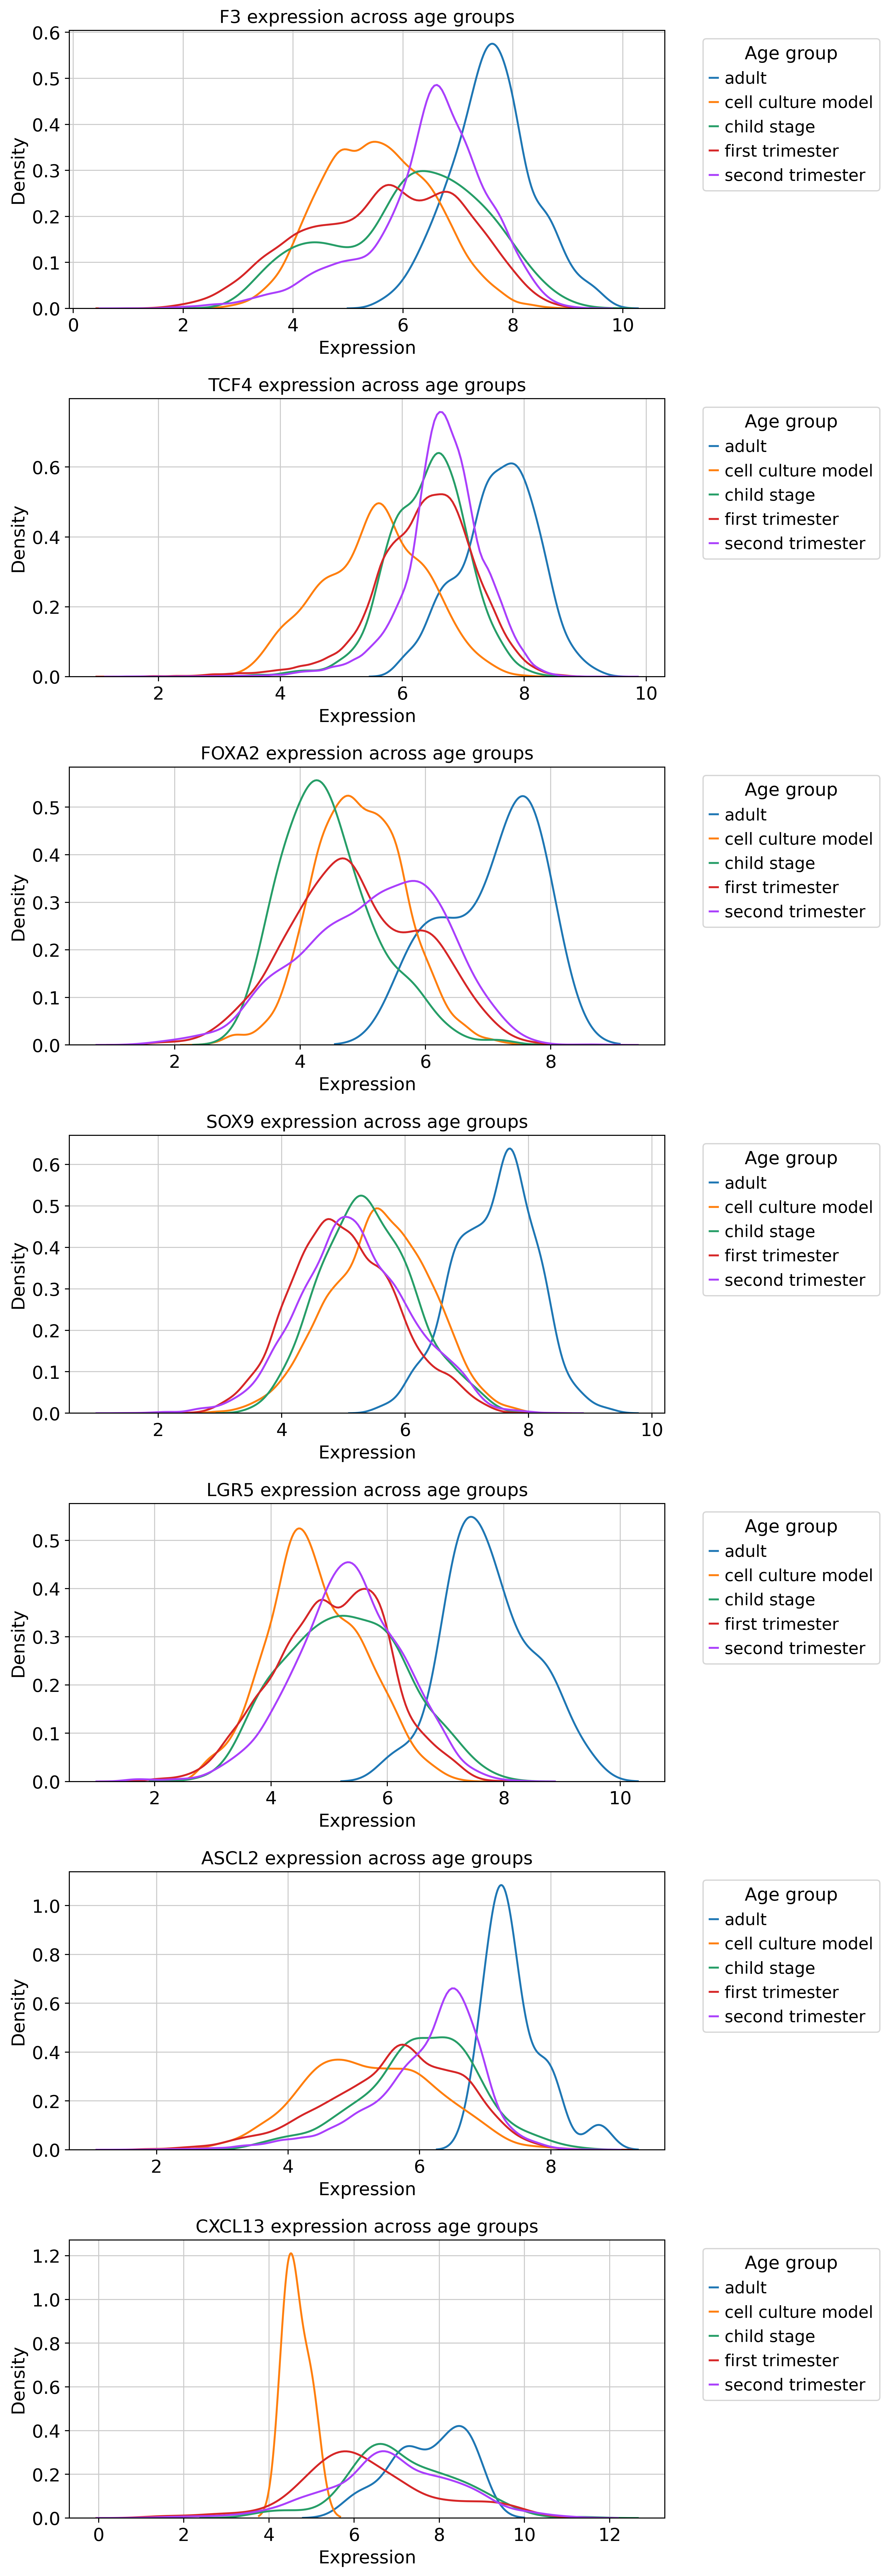

In [42]:
genes_to_plot = ['F3', 'TCF4', 'FOXA2',  'SOX9', 'LGR5', 'ASCL2', 'CXCL13'] 
fig = plot_ridges_for_genes(adata_corrected, genes_to_plot)
plt.show()

In [ ]:
genes_to_plot = ['F3', 'TCF4', 'FOXA2',  'SOX9', 'LGR5', 'ASCL2', 'CXCL13'] 
fig = plot_ridges_for_genes(adata_uncorrected, genes_to_plot)
plt.show()